# HW1: Statistical Learning Perspective & Exploratory Data Analysis

## Due on 27-Jan-2026

### Course: MA 5755 (with rs)

## Dataset
We will use the **Iris dataset**, a classic dataset for exploratory data analysis.

**Tasks**:
1. Load the dataset.
2. Inspect its structure.
3. Perform exploratory visual analysis.
4. Reflect on what you observe.


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## Task 1: Load and Inspect the Data
Load the Iris dataset from `sklearn.datasets` and convert it into a pandas DataFrame.

**Questions to answer (in Markdown below):**
- How many samples and features are there?
- What are the feature names?
- What is the target variable?

In [2]:
# Your code here
from sklearn.datasets import load_iris

iris = load_iris()
# Convert to DataFrame
# TODO: create DataFrame with features and target
#print(iris)
print(iris.DESCR)

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["species"] = iris.target

df.head(), df.shape


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

(   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
 0                5.1               3.5                1.4               0.2   
 1                4.9               3.0                1.4               0.2   
 2                4.7               3.2                1.3               0.2   
 3                4.6               3.1                1.5               0.2   
 4                5.0               3.6                1.4               0.2   
 
    species  
 0        0  
 1        0  
 2        0  
 3        0  
 4        0  ,
 (150, 5))

### Answers:

**How many samples and features are there?**
- The dataset contains **150 samples** and **4 features**.

---

**What are the feature names?**
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

---

**What is the target variable?**
- The target variable is **species**, which has 3 classes: setosa (0), versicolor (1), and virginica (2).

## Task 2: Summary Statistics
Compute basic summary statistics (mean, median, standard deviation) for each feature.

**Questions to answer:**
- Which features show the largest variability?
- Are the feature scales comparable?

In [3]:
# Your code here
# TODO: compute summary statistics
print(df.describe())

print(df.max() - df.min())

df.median(numeric_only=True)

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  
sepal length (cm)    3.6
sepal width (cm)     2.4
petal length (cm)    5

sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
species              1.00
dtype: float64

### Answers:

**Which features show the largest variability?**
- **Petal length** shows the largest absolute variability with a standard deviation of approximately 1.76 (highest among the features). It also has the highest range (5.9 cm).

---

**Are the feature scales comparable?**
- **No, the feature scales are not directly comparable**.
- Sepal length ranges from 4.3 to 7.9 cm (range: 3.6 cm)
- Sepal width ranges from 2.0 to 4.4 cm (range: 2.4 cm)
- Petal length ranges from 1.0 to 6.9 cm (range: 5.9 cm)
- Petal width ranges from 0.1 to 2.5 cm (range: 2.4 cm)
- Because the features have different means and ranges, applying standardization or normalization is often recommended, especially when training machine learning models.
- That said, **the differences are not extreme (not orders of magnitude apart)**, so some algorithms can handle these variations without strict scaling.

## Task 3: Univariate Visualization
Create histograms for each feature.

**Questions to answer:**
- Are the distributions symmetric or skewed?
- Do you observe any potential outliers?

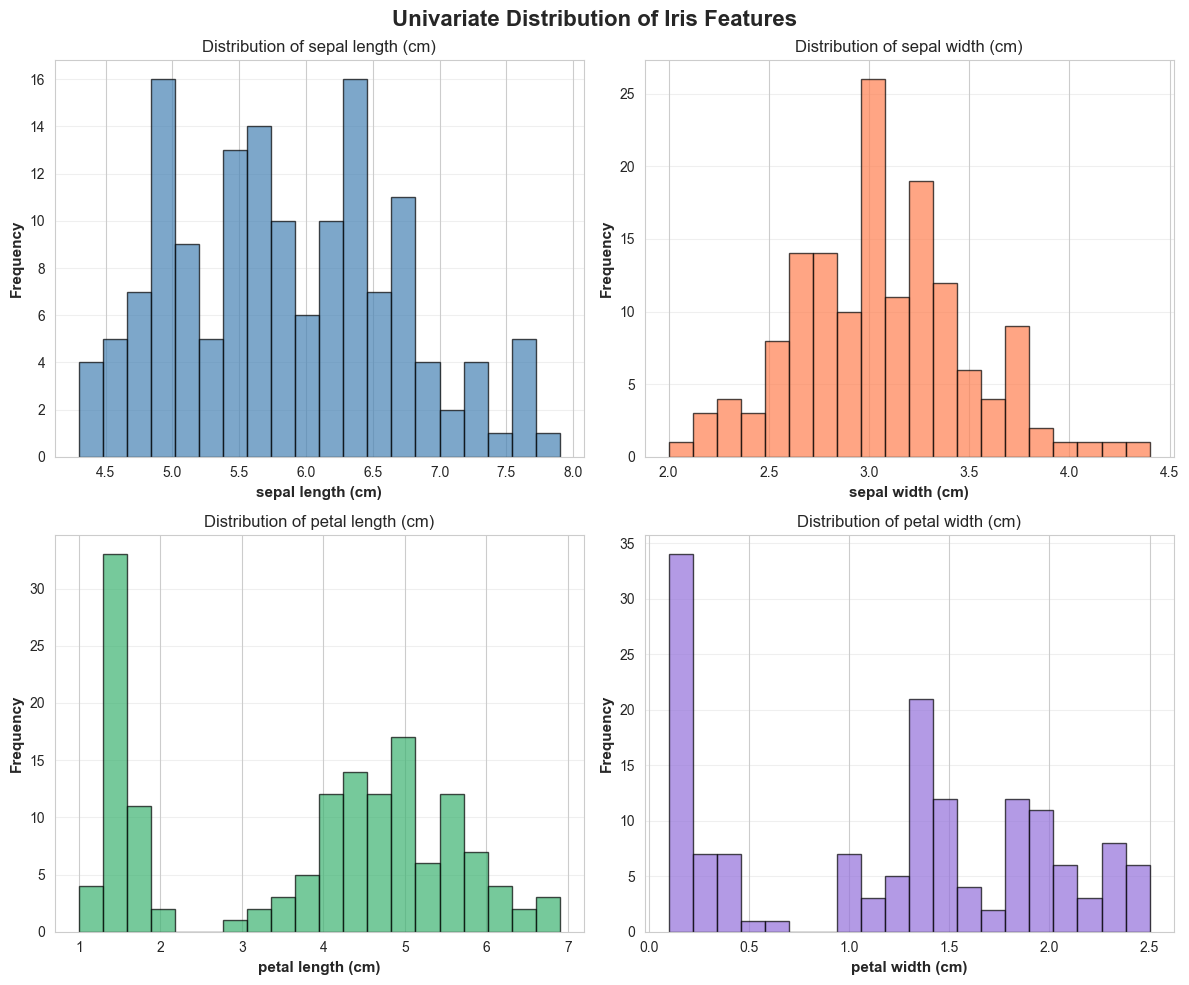

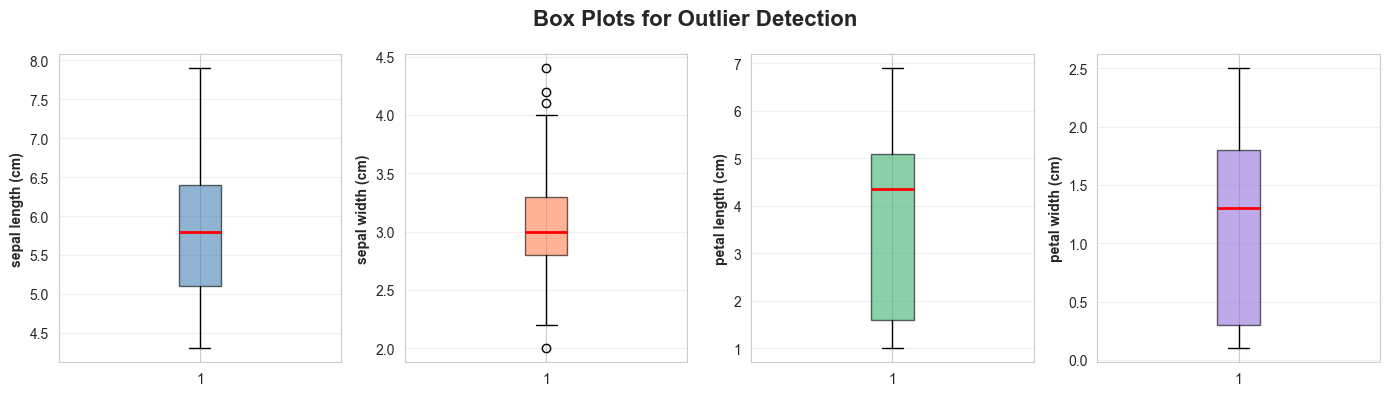

In [4]:
# Create histograms for all features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Univariate Distribution of Iris Features', fontsize=16, fontweight='bold')

features = iris.feature_names
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for idx, (ax, feature, color) in enumerate(zip(axes.flatten(), features, colors)):
    ax.hist(df[feature], bins=20, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution of {feature}', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figs_results/a1_task3_fig1_senthilnathan_t.png', dpi=300, bbox_inches='tight')
plt.show()

# Box plots are best for outlier predictions
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold')

for idx, (ax, feature, color) in enumerate(zip(axes, features, colors)):
    ax.boxplot(df[feature], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_ylabel(feature, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figs_results/a1_task3_fig2_senthilnathan_t.png', dpi=300, bbox_inches='tight')
plt.show()

### Answers:

**Are the distributions symmetric or skewed?**

- **Sepal length**: 
    - Overall distribution is approximately symmetric, though it shows a **slight right skew** (a longer tail toward larger values).
    - Additionally, I also see three peaks and the distribution looks like a mixture of three gaussians.

- **Sepal width**: 
    - Overall, the distribution is **approximately symmetric**.
    - But I am able to observe three peaks in this distribution too (around 2.6, 3.0 and 3.7 cm). 

- **Petal length**: 
    - The distribution is **strongly skewed** and **majorly bimodal** with two distinct peaks. 
    - This strong bimodality suggests that there are at least two distinct groups in the data. 
    - One group has smaller petal lengths (around 1-2 cm) and another has larger petal lengths (around 4-6 cm).

- **Petal width**: 
    - Also exhibits majorly a **bimodal distribution** similar to petal length, with one peak near 0-0.5 cm and another around 1.5-2.0 cm.
    - The distribution in the right side seems to have two peaks in it (one around 1.4 and another around 1.8). 

---

**Do you observe any potential outliers?**

From the box plots, we can identify potential outliers:

- **Sepal width**: 
    - The box plot shows no strong outliers.
    - Most values fall within the whiskers.

- **Sepal length**: There are a few potential outliers, especially on the upper end (around 4.1–4.4 cm) and somewhat on the lower end.

- **Petal length and Petal width**: 
    - No major outliers are evident from the box plot.
    - The wide spread is mostly due to the bimodal nature.

**Another observation**: The bimodal distributions in petal length and width also suggest that the iris species can be distinguished based on these features.

## Task 4: Bivariate Visualization
Create scatter plots for at least two different pairs of features.

**Questions to answer:**
- Do you observe any clustering or separation?
- Which features appear most informative visually?

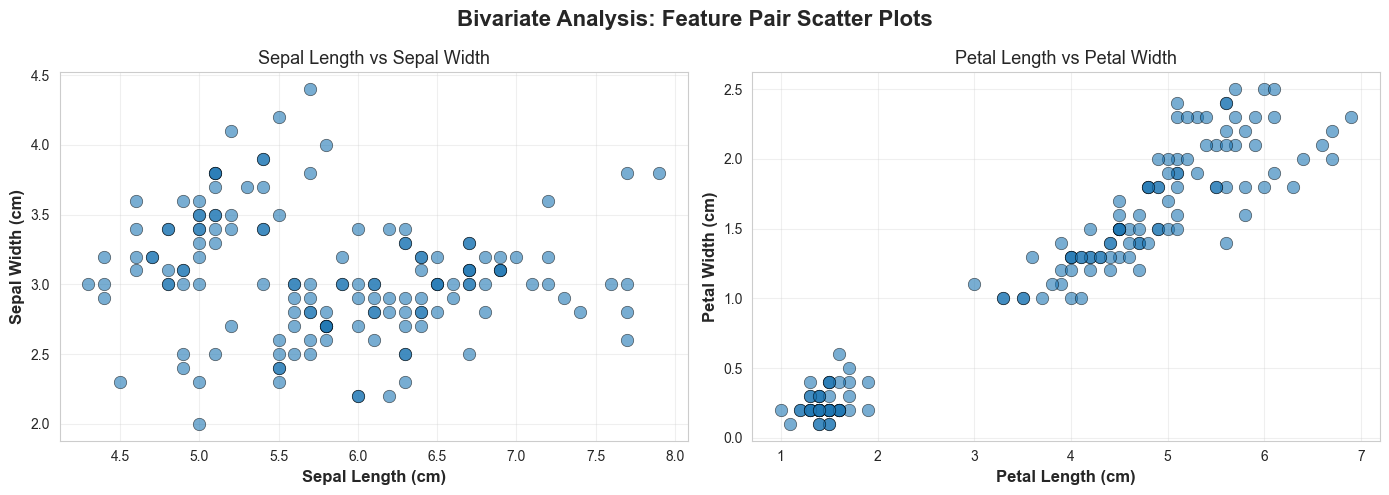

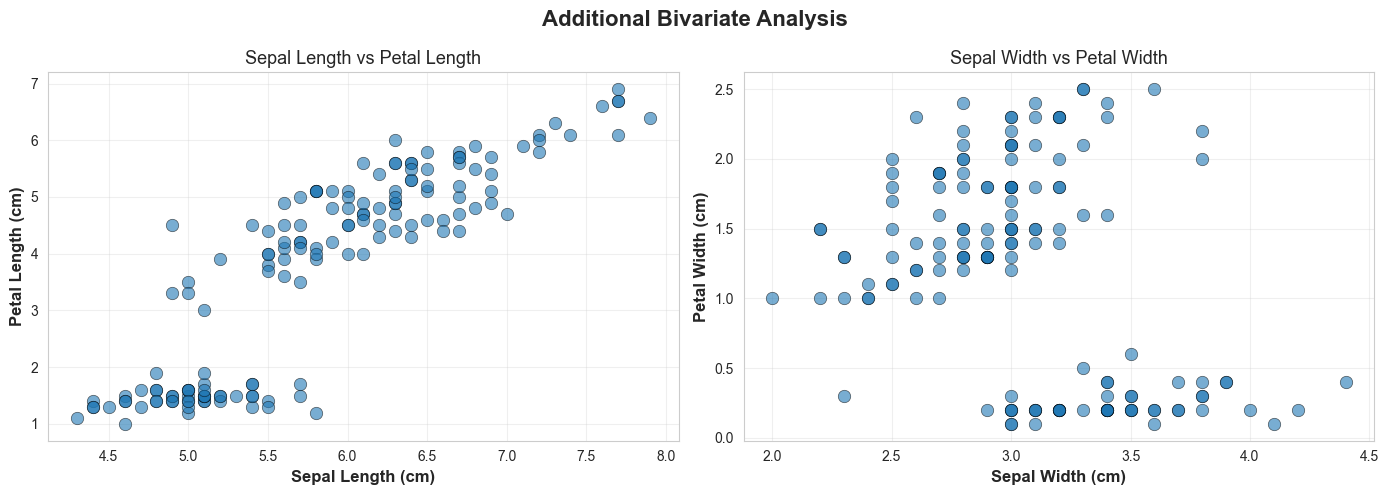

In [5]:
# Create scatter plots for different feature pairs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bivariate Analysis: Feature Pair Scatter Plots', fontsize=16, fontweight='bold')

# Pair 1: Sepal features
axes[0].scatter(df['sepal length (cm)'], df['sepal width (cm)'], 
                alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Sepal Length (cm)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sepal Width (cm)', fontsize=12, fontweight='bold')
axes[0].set_title('Sepal Length vs Sepal Width', fontsize=13)
axes[0].grid(alpha=0.3)

# Pair 2: Petal features
axes[1].scatter(df['petal length (cm)'], df['petal width (cm)'], 
                alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Petal Length (cm)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Petal Width (cm)', fontsize=12, fontweight='bold')
axes[1].set_title('Petal Length vs Petal Width', fontsize=13)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figs_results/a1_task4_fig1_senthilnathan_t.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional scatter plots for comprehensive analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Additional Bivariate Analysis', fontsize=16, fontweight='bold')

# Pair 3: Sepal length vs Petal length
axes[0].scatter(df['sepal length (cm)'], df['petal length (cm)'], 
                alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Sepal Length (cm)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Petal Length (cm)', fontsize=12, fontweight='bold')
axes[0].set_title('Sepal Length vs Petal Length', fontsize=13)
axes[0].grid(alpha=0.3)

# Pair 4: Sepal width vs Petal width
axes[1].scatter(df['sepal width (cm)'], df['petal width (cm)'], 
                alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Sepal Width (cm)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Petal Width (cm)', fontsize=12, fontweight='bold')
axes[1].set_title('Sepal Width vs Petal Width', fontsize=13)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figs_results/a1_task4_fig2_senthilnathan_t.png', dpi=300, bbox_inches='tight')
plt.show()

### Answers:

**Do you observe any clustering or separation?**

Yes, distinct clustering patterns are observable, particularly in certain feature pairs:

- **Petal Length vs Petal Width**: This scatter plot shows **very clear clustering and separation**. There appears to be at least two distinct groups:
  - A tight cluster in the lower-left region (small petal length and width)
  - A more diffuse cluster in the upper-right region (larger petal length and width)
  - There's a clear linear relationship between petal length and width, with very little overlap between clusters.

- **Sepal Length vs Sepal Width**: 
    - Shows **least clear clustering** among these observations. 
    - The points are more scattered, though there are hints of multiple groups. Majorly we are able to see two clusters. Though the separation is not as pronounced as we see among the petal features (petal length vs petal width).

- **Sepal Length vs Petal Length**: 
    - Displays **moderate clustering** with some separation visible.
    - A clear separation exists for smaller petal lengths.
    - Larger petal lengths form another broader cluster.

-  **Sepal Width vs Petal Width**: 
    - Also displays **moderate clustering** with some separation visible.
    - Petal width still helps separate clusters, though sepal width adds less discriminative power.

---

**Which features appear most informative visually?**

Based on the scatter plots:

1. **Petal features (length and width) are the most informative**:
   - They show the clearest separation between groups
   - The clusters are well-defined and distinct
   - There's a strong positive correlation between petal length and width
   - These features would likely be excellent for classification tasks

2. **Sepal features are less informative individually**:
   - The clustering is less obvious
   - There's more overlap between potential groups
   - However, they might still contribute useful information when combined with petal features

**Key observation**: The petal measurements appear to be the most discriminative features for distinguishing iris species.

## Task 5: Visualization with Labels
Color the scatter plots using the species labels.

**Questions to answer:**
- Does labeling change your interpretation?
- Which classes appear easiest or hardest to separate visually?

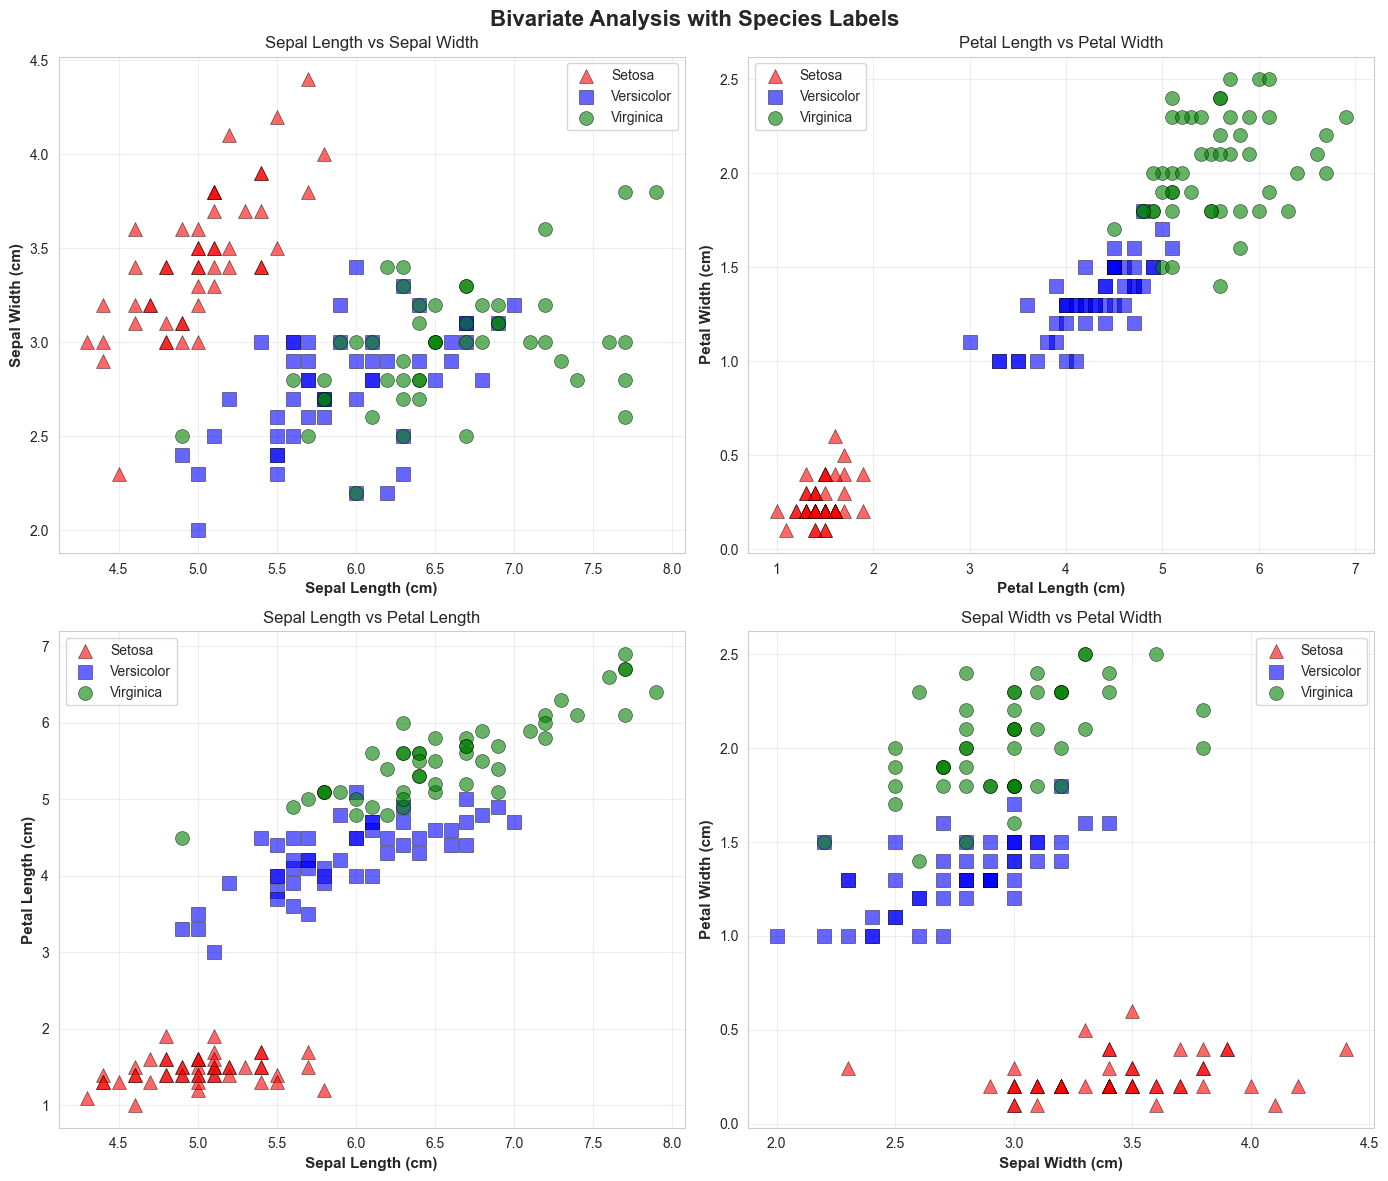

In [6]:
# Create labeled scatter plots with different markers for each species
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Bivariate Analysis with Species Labels', fontsize=16, fontweight='bold')

# Define colors and markers for each species
# Instead of just colors, we also use different shaped markers (better for colorblindness).
# Triangle for Setosa, Square for Versicolor, Circle for Virginica
colors_map = {0: 'red', 1: 'blue', 2: 'green'}
markers_map = {0: '^', 1: 's', 2: 'o'}  # ^ = triangle, s = square, o = circle
species_names = ['Setosa', 'Versicolor', 'Virginica']

# Plot 1: Sepal features
for species in range(3):
    mask = df['species'] == species
    axes[0, 0].scatter(df.loc[mask, 'sepal length (cm)'], 
                       df.loc[mask, 'sepal width (cm)'],
                       c=colors_map[species], label=species_names[species],
                       marker=markers_map[species],
                       alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Sepal Length (cm)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Sepal Width (cm)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Sepal Length vs Sepal Width', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Petal features
for species in range(3):
    mask = df['species'] == species
    axes[0, 1].scatter(df.loc[mask, 'petal length (cm)'], 
                       df.loc[mask, 'petal width (cm)'],
                       c=colors_map[species], label=species_names[species],
                       marker=markers_map[species],
                       alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[0, 1].set_xlabel('Petal Length (cm)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Petal Width (cm)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Petal Length vs Petal Width', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Sepal length vs Petal length
for species in range(3):
    mask = df['species'] == species
    axes[1, 0].scatter(df.loc[mask, 'sepal length (cm)'], 
                       df.loc[mask, 'petal length (cm)'],
                       c=colors_map[species], label=species_names[species],
                       marker=markers_map[species],
                       alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Sepal Length (cm)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Petal Length (cm)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Sepal Length vs Petal Length', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Sepal width vs Petal width
for species in range(3):
    mask = df['species'] == species
    axes[1, 1].scatter(df.loc[mask, 'sepal width (cm)'], 
                       df.loc[mask, 'petal width (cm)'],
                       c=colors_map[species], label=species_names[species],
                       marker=markers_map[species],
                       alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Sepal Width (cm)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Petal Width (cm)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Sepal Width vs Petal Width', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figs_results/a1_task5_fig1_senthilnathan_t.png', dpi=300, bbox_inches='tight')
plt.show()

### Answers:

**Does labeling change your interpretation?**

Yes, **labeling significantly changes and enhances the interpretation** of the data:

1. **Confirms clustering hypotheses**: The clusters we observed in Task 4 now clearly correspond to the three iris species. Without labels, the clusters appear as general groupings, but it is unclear what they represent.

2. **Reveals linear separability**: With labels, we can see that Setosa (red) is **linearly separable** from the other two species in most feature combinations, especially in petal measurements.

3. **Shows class overlap**: The labeling reveals that Versicolor (blue) and Virginica (green) have **some overlap** in certain feature spaces, which wasn't apparent from the unlabeled data.

4. **Explains bimodal distributions**: The bimodal distributions we observed in Task 3 for petal features now make perfect sense:
   - One mode corresponds to Setosa (smaller petals)
   - The other mode represents Versicolor and Virginica combined (larger petals)

5. **Highlights feature importance**: We can now clearly see which features best discriminate between species, confirming our hypothesis that petal features are most informative.

---

**Which classes appear easiest or hardest to separate visually?**

**Easiest to separate:**
- **Setosa is the easiest class to separate** from the other two species:
  - It forms a tight, well-defined cluster in all feature combinations
  - It has distinctly smaller petal measurements (both length and width)
  - There is **no overlap** with the other species in petal feature space
  - Even in sepal feature space, where separation is less clear, Setosa still shows minimal overlap
  - A simple linear classifier could easily separate Setosa from the others

**Hardest to separate:**
- **Versicolor and Virginica are the hardest to separate** from each other:
  - They show **significant overlap** in all feature spaces
  - In sepal measurements, the overlap is substantial, making it difficult to distinguish between them using only these features
  - Even in petal feature space (where they're most distinguishable), their clusters are only partially separated
  - Virginica generally has larger measurements than Versicolor, but the boundary between them is not sharp
  - A more sophisticated classifier (non-linear or using multiple features) would be needed to effectively separate these two classes

**Key observations by feature pair:**
- **Petal Length vs Petal Width**: Best separation overall; Setosa is completely separate, while Versicolor and Virginica have minimal overlap
- **Sepal Length vs Sepal Width**: Worst separation
- **Cross-feature combinations**: Moderate separation, better than sepal-only but not as good as petal-only

## Task 6: Reflection
Answer the following in **your own words**:


1. Why is exploratory data analysis important before modeling?
2. What could go wrong if we skip visualization?
3. Which feature(s) would you expect to be useful for classification, and why?


## Answer

### **1. Why is exploratory data analysis important before modeling?**

Exploratory Data Analysis (EDA) is really important because it helps us understand what the dataset looks like before jumping into machine learning models. By doing EDA, we can check if the data has problems such as outliers, missing values, or unusual patterns that could affect the model. For example, in the Iris dataset we noticed a few possible outliers in sepal width.

EDA also helps us understand how each feature is distributed and whether the feature scales are very different, which tells us if preprocessing like standardization might be needed. Most importantly, it helps us see relationships between features. In our case, petal length and petal width showed a strong connection and clear clustering between species. Overall, EDA gives us intuition about the data and helps us make better decisions before modeling.

---

### **2. What could go wrong if we skip visualization?**

If we skip visualization, we might miss important details in the dataset. Without plots such as histograms, box plots, and scatter plots, we may fail to notice skewed or multimodal distributions, outliers, or differences in feature scales. We could also overlook which features actually separate the classes well.

For instance, without scatter plots, we wouldn’t realize that petal features clearly distinguish Setosa, while sepal features overlap a lot between species. Skipping EDA could lead to wrong preprocessing choices, selecting unsuitable models, and not understanding why the model performs poorly on certain classes. Visualization helps avoid these mistakes and makes the modeling process much more reliable.

---

### **3. Which feature(s) would you expect to be useful for classification, and why?**

From the plots, it is clear that **petal length** and **petal width** are the most useful features for classification. These two features show the strongest separation between the species, especially because Setosa forms a completely distinct cluster with very small petal values.

Sepal length and sepal width are less helpful by themselves since Versicolor and Virginica overlap a lot in sepal-based plots. However, using all four features together could still improve accuracy, especially when distinguishing between the harder classes.

So overall, petal measurements seem to provide the most important information for predicting the species.
